# STAT 547E — Assignment 2: Starter Notebook
### Problem 3: ELE failure and the cost of poor mixing

Submit a single PDF with all plots and written answers.

In [1]:
using Distributions, Plots, Statistics, Random
gr()

Plots.GRBackend()

In [2]:
log_incr_weight(x, Δβ, μ) = Δβ .* (μ .* x .- μ^2 / 2)
# I'm pretty sure this incrementing code is completely wrong

function logsumexp(v)
    m = maximum(v)
    return m + log(sum(exp.(v .- m)))
end

"Systematic resampling. Returns N indices proportional to weights w."
function systematic_resample(w, N, rng)
    cumw = cumsum(w ./ sum(w))
    u    = (rand(rng) .+ (0:N-1)) ./ N
    idx  = zeros(Int, N)
    j    = 1
    for i in 1:N
        while cumw[j] < u[i]; j += 1; end
        idx[i] = j
    end
    return idx
end

"AIS estimate of log Z under ELE (exact sampling at each temperature)."
function ais_ele(μ, T, N; rng=default_rng())
    βs   = range(0.0, 1.0, length=T+1)
    logW = zeros(N)
    for t in 1:T
        X     = randn(rng, N) .+ βs[t] * μ
        logW .+= log_incr_weight(X, βs[t+1]-βs[t], μ)
    end
    return logsumexp(logW) - log(N)
end

"SIR estimate of log Z under ELE with systematic resampling."
# Since this is perfect sampling systematic resampling is not actually
# necessary, and is skipped in this code
function sir_ele(μ, T, N; rng=default_rng())
    βs   = range(0.0, 1.0, length=T+1)
    logZ = 0.0
    for t in 1:T
        X    = randn(rng, N) .+ βs[t] * μ
        logw = log_incr_weight(X, βs[t+1]-βs[t], μ)
        logZ += logsumexp(logw) - log(N)
    end
    return logZ
end

"AIS with k RWM steps per temperature."
function ais_rwm(μ, T, N, k, σ_prop; rng=default_rng())
    βs   = range(0.0, 1.0, length=T+1)
    X    = randn(rng, N)
    logW = zeros(N)
    for t in 1:T
        logW .+= log_incr_weight(X, βs[t+1]-βs[t], μ)
        for _ in 1:k
            X_prop = X .+ σ_prop .* randn(rng, N)
            log_α  = -0.5*(X_prop .- βs[t+1]*μ).^2 .+
                      0.5*(X      .- βs[t+1]*μ).^2
            accept = log.(rand(rng, N)) .< log_α
            X[accept] = X_prop[accept]
        end
    end
    return logsumexp(logW) - log(N)
end

"SIR with k RWM steps per temperature and systematic resampling."
function sir_rwm(μ, T, N, k, σ_prop; rng=default_rng())
    βs   = range(0.0, 1.0, length=T+1)
    X    = randn(rng, N)
    logZ = 0.0
    for t in 1:T
        logw = log_incr_weight(X, βs[t+1]-βs[t], μ)
        logZ += logsumexp(logw) - log(N)
        w    = exp.(logw .- maximum(logw))
        idx  = systematic_resample(w, N, rng)
        X    = X[idx]
        for _ in 1:k
            X_prop = X .+ σ_prop .* randn(rng, N)
            log_α  = -0.5*(X_prop .- βs[t+1]*μ).^2 .+
                      0.5*(X      .- βs[t+1]*μ).^2
            accept = log.(rand(rng, N)) .< log_α
            X[accept] = X_prop[accept]
        end
    end
    return logZ
end

"Run est_fn M times at each T in T_grid. Returns (means, stds) of log Ẑ."
function logz_stats(est_fn, T_grid, M)
    means, stds = Float64[], Float64[]
    for T in T_grid
        runs = [est_fn(T) for _ in 1:M]
        push!(means, mean(runs))
        push!(stds,  std(runs))
    end
    return means, stds
end

const M_REP = 200  


200

---
## Part (a): AIS — varying $k$

In [3]:
ks  = [1, 5, 20, 100]
N = 100
μ = 10
σ_prop = 0.5
seed = 42
# From previous work we know Λ is 10, thus we don't really need
# that many levels
T_grid = [1, 2, 3, 4, 5, 10, 15, 20, 25, 50, 75, 100, 125]

function experiment(rwm_func, ele_func)
    all_means = []
    all_stds = []
    labels = []

    # Finite walk RWM
    for k in ks
        est_fn(T) = rwm_func(μ, T, N, k, σ_prop; rng=Random.default_rng(seed))
        means, stds = logz_stats(est_fn, T_grid, M_REP)
        push!(all_means, means)
        push!(all_stds, stds)
        push!(labels, "k = $k")
    end

    # Compute ELE estimate
    est_ele(T) = ele_func(μ, T, N; rng=Random.default_rng(seed))
    ele_means, ele_stds = logz_stats(est_ele, T_grid, M_REP)

    push!(all_means, ele_means)
    push!(all_stds, ele_stds)
    push!(labels, "k = ∞")

    # plot(plots..., ylims=(-40, 5))

    plots = []
    # ymin = minimum([minimum(means .- stds) for (means, stds) in zip(all_means, all_stds)])
    # ymax = maximum([maximum(means .+ stds) for (means, stds) in zip(all_means, all_stds)])
    Λ = μ # see exercise 2

    p = plot(
        xlabel="log10 T",
        ylabel="Estimate of log Z",
    )

    for (means, stds, label) in zip(all_means, all_stds, labels)
        plot!(p,
            log10.(T_grid),
            means,
            ribbon=stds,
            alpha = 0.1,
            lw = 2,
            label = label
        )
        # push!(plots, p)
    end
    vline!([log10(Λ)], label = "T=Λ")
    vline!([2*log10(Λ)], label= "T=Λ^2")
    return p, all_means, all_stds, labels
end

experiment (generic function with 1 method)

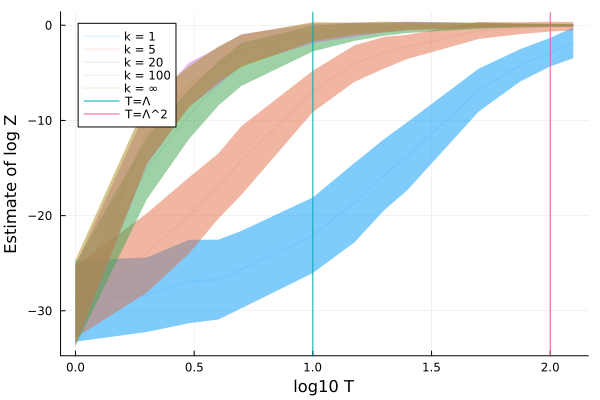

"/Users/zacharylau/Desktop/School/2025-26/Sampling/homework/homework2/graphics/ais.png"

In [4]:
p, ais_mean, ais_std, labels = experiment(ais_rwm, ais_ele)
display(p)
savefig("./graphics/ais.png")

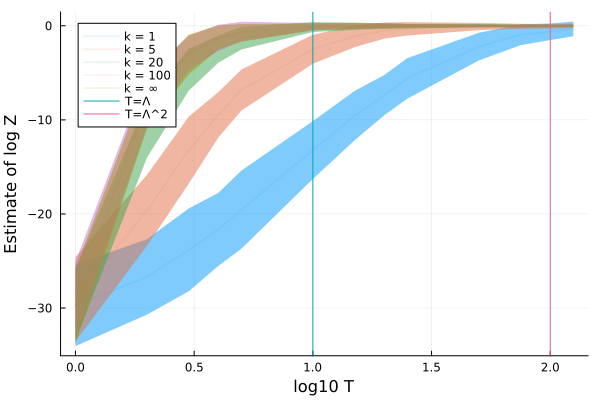

"/Users/zacharylau/Desktop/School/2025-26/Sampling/homework/homework2/graphics/sir.png"

In [5]:
p, sir_mean, sir_std, labels = experiment(sir_rwm, sir_ele)
display(p)
savefig("./graphics/sir.png")

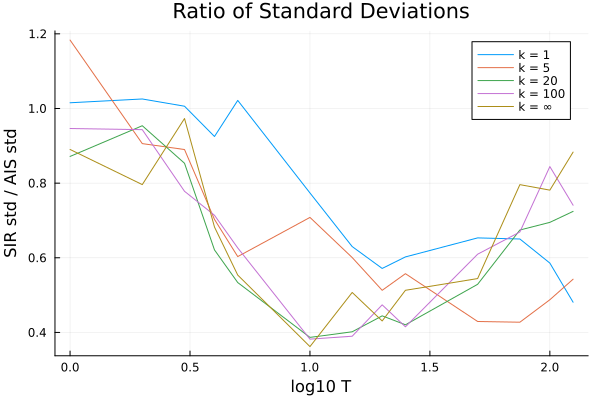

"/Users/zacharylau/Desktop/School/2025-26/Sampling/homework/homework2/graphics/ratios.png"

In [6]:
ratios = [a ./ b for (a,b) in zip(sir_std, ais_std)]
p = plot(log10.(T_grid), ratios, label = permutedims(labels),
    title="Ratio of Standard Deviations",
    xlabel="log10 T",
    ylabel="SIR std / AIS std")
display(p)
savefig("./graphics/ratios.png")

**Write your observations here.**

- At what $k$ does the band converge to the ELE baseline?
- By what factor in $T$ does $k=1$ inflate the required schedule?

By $k=20$ we have practically converged to the ELE baseline. The 

---
## Part (b): SIR — varying $k$

**Write your observations here.**

- Does resampling change the $k$ at which ELE kicks in?
- At small $k$, is the SIR band wider or narrower than AIS?

See code above. Resampling didn't really help w

---
## Part (c): Equal budget — few steps + good mixing vs many steps + poor mixing

In [8]:
function experiment2(rwm_func, ele_func)
    seed = 42
    all_means = []
    all_stds = []
    labels = []
    for (k, T) in [(1, 2000), (20, 100)]
        est_fn(T) = rwm_func(μ, T, N, k, σ_prop; rng=Random.default_rng(seed))
        means, stds = logz_stats(est_fn, [T], M_REP)
        push!(all_means, means[1])
        push!(all_stds, stds[1])
        push!(labels, "k = $k; T = $T")
    end
    est_ele(T) = ele_func(μ, T, N; rng=Random.default_rng(seed))
    ele_means, ele_stds = logz_stats(est_ele, [100], M_REP)
    push!(all_means, ele_means[1])
    push!(all_stds, ele_stds[1])
    push!(labels, "ELE; T = 100")
    return all_means, all_stds, labels
end

experiment2 (generic function with 1 method)

In [9]:
using DataFrames, CSV, Printf

In [10]:
function make_df(means, stds, labels)
    fmt(x) = @sprintf("%.3f", x)
    df = DataFrame(
        run = labels,
        mean = fmt.(means),
        std = fmt.(stds),
        se = fmt.(stds ./ sqrt(2*(M_REP-1)))
    )
end

make_df (generic function with 1 method)

In [11]:
ais_df = make_df(experiment2(ais_rwm, ais_ele)...)
CSV.write("ais.csv", ais_df)
ais_df

Row,run,mean,std,se
,Any,String,String,String
1,k = 1; T = 2000,-0.022,0.130,0.007
2,k = 20; T = 100,-0.030,0.161,0.008
3,ELE; T = 100,0.004,0.126,0.006


In [12]:
sir_df = make_df(experiment2(sir_rwm, sir_ele)...)
CSV.write("sir.csv", sir_df)
sir_df

Row,run,mean,std,se
,Any,String,String,String
1,k = 1; T = 2000,-0.008,0.115,0.006
2,k = 20; T = 100,-0.016,0.118,0.006
3,ELE; T = 100,-0.007,0.091,0.005


**Write your observations here.**

- Which strategy gives a better estimate at the same budget $B = T \times k = 2000$?
- Is the advantage larger for AIS or SIR? Why?